# Part 3 — Adversarial Attacks: Breaking the Classifier
**Assignment:** Responsible & Explainable AI — FAST-NUCES  
**Goal:** Implement and evaluate two adversarial attacks — character-level evasion and label-flipping poisoning — then document the attack surface of the production classifier.

**Prerequisite:** `part1.ipynb` must have been run first. This notebook loads:
- `/kaggle/working/distilbert-jigsaw-final/` — clean baseline model checkpoint
- `/kaggle/working/eval_with_preds.csv` — evaluation set with predictions + identity columns
- `/kaggle/working/train_split.csv` — training split (for poisoning attack retraining)

## Cell 1 — Install / verify dependencies

In [1]:
!pip install -q --upgrade accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 7.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 69.1 MB/s eta 0:00:00:00:010:01


## Cell 2 — Imports and reproducibility

In [2]:
import os
import re
import random
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    EvalPrediction,
)

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Cell 3 — Load artefacts from Part 1

In [3]:
MODEL_DIR  = '/kaggle/input/datasets/i220453emadhasan/jigsaw-final'
MAX_LEN    = 128

# Load eval set (with Part 1 predictions already attached)
df_eval  = pd.read_csv('/kaggle/input/datasets/i220453emadhasan/results/eval_with_preds.csv')
df_train = pd.read_csv('/kaggle/input/datasets/i220453emadhasan/results/train_split.csv')

print(f'Eval  set : {len(df_eval):,} rows')
print(f'Train set : {len(df_train):,} rows')
print(f'Eval columns: {list(df_eval.columns)}')

# Load the clean baseline model + tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
clean_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
clean_model = clean_model.to(DEVICE)
clean_model.eval()
print('\nBaseline model loaded and set to eval mode.')

Eval  set : 20,000 rows
Train set : 100,000 rows
Eval columns: ['comment_text', 'label', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian', 'prob_toxic', 'pred_05']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Baseline model loaded and set to eval mode.


## Cell 4 — Inference helper (shared by both attacks)

In [4]:
class TextDataset(Dataset):
    """Minimal dataset for inference — no labels needed."""
    def __init__(self, texts, tokenizer, max_len):
        self.texts     = list(texts)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }


@torch.no_grad()
def get_probs(model, texts, tokenizer, max_len=128, batch_size=64):
    """
    Run batched inference and return P(toxic) for every text.
    Returns numpy array of shape (N,).
    """
    dataset = TextDataset(texts, tokenizer, max_len)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    all_probs = []

    model.eval()
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

    return np.array(all_probs)


print('Inference helper defined.')

Inference helper defined.


---
# ATTACK 1 — Character-level Evasion

**Threat model:** A bad actor wants to post toxic content without being caught. They run their comment through a perturbation script that makes character-level changes invisible to human readers but that destroy the subword tokenisation patterns the model depends on.

## Cell 5 — `perturb()` function

In [5]:
# ── Homoglyph map: Latin → visually identical Unicode lookalikes ─────────────
# Each substitution produces a character that renders identically in most fonts
# but hashes to a different Unicode code point, creating OOV subword tokens.
HOMOGLYPH_MAP = {
    'a': '\u0430',   # Cyrillic small а
    'e': '\u0435',   # Cyrillic small е
    'o': '\u043e',   # Cyrillic small о
    'p': '\u0440',   # Cyrillic small р
    'c': '\u0441',   # Cyrillic small с
    'x': '\u0445',   # Cyrillic small х
    'i': '\u0456',   # Cyrillic small і (Ukrainian)
    'A': '\u0410',   # Cyrillic capital А
    'E': '\u0415',   # Cyrillic capital Е
    'O': '\u041e',   # Cyrillic capital О
    'B': '\u0412',   # Cyrillic capital В
    'H': '\u041d',   # Cyrillic capital Н
    'K': '\u041a',   # Cyrillic capital К
    'M': '\u041c',   # Cyrillic capital М
    'T': '\u0422',   # Cyrillic capital Т
    'X': '\u0425',   # Cyrillic capital Х
}

ZERO_WIDTH_SPACE = '\u200b'   # U+200B — invisible to human readers, visible to tokenizer


def _insert_zero_width_spaces(word: str) -> str:
    """
    Insert U+200B between every 2–3 characters in the word.
    The gap is randomised per call so identical words produce different tokens,
    making the attack harder to detect via exact-match filters.
    """
    if len(word) < 3:
        return word
    result = []
    i = 0
    while i < len(word):
        step = random.randint(2, 3)
        result.append(word[i:i + step])
        i += step
    return ZERO_WIDTH_SPACE.join(result)


def _apply_homoglyphs(word: str) -> str:
    """
    Replace Latin characters with Cyrillic homoglyphs.
    Only substitutes characters present in HOMOGLYPH_MAP.
    """
    return ''.join(HOMOGLYPH_MAP.get(ch, ch) for ch in word)


def _duplicate_chars(word: str, rate: float = 0.20) -> str:
    """
    With probability `rate`, duplicate each character in the word.
    'hate' → 'haate'. Breaks n-gram and BPE subword patterns.
    """
    result = []
    for ch in word:
        result.append(ch)
        if random.random() < rate:
            result.append(ch)   # duplicate
    return ''.join(result)


def perturb(text: str) -> str:
    """
    Apply all three character-level evasion transformations to `text`.

    Pipeline (applied per token / word):
      1. Zero-width space insertion  — splits subword tokenisation
      2. Homoglyph substitution      — produces OOV/unknown subwords
      3. Character duplication       — breaks BPE n-gram patterns

    Punctuation and whitespace tokens are left unmodified so the text
    remains human-readable.
    """
    # Tokenise on whitespace to preserve original spacing
    tokens = text.split(' ')
    perturbed_tokens = []

    for token in tokens:
        # Separate leading/trailing punctuation so we only mangle word stems
        match = re.match(r'^([^\w]*)(\w+)([^\w]*)$', token)
        if match:
            prefix, word, suffix = match.groups()
            word = _apply_homoglyphs(word)         # Step 2 first (works on original chars)
            word = _duplicate_chars(word, 0.20)    # Step 3
            word = _insert_zero_width_spaces(word) # Step 1 last (wraps the whole modified word)
            perturbed_tokens.append(prefix + word + suffix)
        else:
            # Pure punctuation or whitespace-only token — leave untouched
            perturbed_tokens.append(token)

    return ' '.join(perturbed_tokens)


# ── Quick sanity demo ────────────────────────────────────────────────────────
demo_texts = [
    "You are a terrible person and I hate you.",
    "This is absolute garbage content.",
    "Kill yourself loser.",
]
print('Perturbation demo:')
print(f'{"─"*60}')
for t in demo_texts:
    p = perturb(t)
    print(f'ORIGINAL  : {t}')
    print(f'PERTURBED : {p}')
    print(f'  Len original={len(t)} | perturbed={len(p)} | repr={repr(p[:60])}...')
    print()

Perturbation demo:
────────────────────────────────────────────────────────────
ORIGINAL  : You are a terrible person and I hate you.
PERTURBED : Yо​оu аr​е аа ttе​rr​іb​lе рее​rsо​оn​n аnd I hа​tе yо​u.
  Len original=41 | perturbed=57 | repr='Yо\u200bоu аr\u200bе аа ttе\u200brr\u200bіb\u200blе рее\u200brsо\u200bоn\u200bn аnd I hа\u200btе yо\u200bu.'...

ORIGINAL  : This is absolute garbage content.
PERTURBED : Тh​іs іs аа​bsо​lu​tе gа​rbb​аgе соn​ntt​еnt.
  Len original=33 | perturbed=45 | repr='Тh\u200bіs іs аа\u200bbsо\u200blu\u200btе gа\u200brbb\u200bаgе соn\u200bntt\u200bеnt.'...

ORIGINAL  : Kill yourself loser.
PERTURBED : Кі​ll​l yо​ur​rsе​lf llо​sе​r.
  Len original=20 | perturbed=30 | repr='Кі\u200bll\u200bl yо\u200bur\u200brsе\u200blf llо\u200bsе\u200br.'...



## Cell 6 — Select the 500-comment attack sample

In [6]:
ATTACK_SAMPLE_SIZE  = 500
CONFIDENCE_THRESHOLD = 0.70   # Only use high-confidence toxic predictions

# Filter: model predicted toxic (pred_05==1) AND confidence >= 0.7
high_conf_toxic = df_eval[
    (df_eval['pred_05'] == 1) &
    (df_eval['prob_toxic'] >= CONFIDENCE_THRESHOLD)
].copy()

print(f'High-confidence toxic predictions (conf >= {CONFIDENCE_THRESHOLD}): {len(high_conf_toxic):,}')

# Sample 500 (or all if fewer exist)
n_sample = min(ATTACK_SAMPLE_SIZE, len(high_conf_toxic))
df_attack = high_conf_toxic.sample(n=n_sample, random_state=SEED).reset_index(drop=True)

print(f'Attack sample selected : {len(df_attack):,} comments')
print(f'Mean confidence        : {df_attack["prob_toxic"].mean():.4f}')
print(f'Min  confidence        : {df_attack["prob_toxic"].min():.4f}')

High-confidence toxic predictions (conf >= 0.7): 968
Attack sample selected : 500 comments
Mean confidence        : 0.8939
Min  confidence        : 0.7006


## Cell 7 — Apply perturbation and run inference

In [7]:
print('Applying perturbations …')
df_attack['perturbed_text'] = df_attack['comment_text'].apply(perturb)
print(f'Perturbation complete. Example:')
print(f'  ORIG : {df_attack["comment_text"].iloc[0][:100]}')
print(f'  PERT : {df_attack["perturbed_text"].iloc[0][:100]}')

print('\nRunning inference on ORIGINAL texts …')
probs_original = get_probs(
    clean_model, df_attack['comment_text'].tolist(),
    tokenizer, MAX_LEN, batch_size=64
)

print('Running inference on PERTURBED texts …')
probs_perturbed = get_probs(
    clean_model, df_attack['perturbed_text'].tolist(),
    tokenizer, MAX_LEN, batch_size=64
)

df_attack['prob_orig']  = probs_original
df_attack['prob_pert']  = probs_perturbed
df_attack['pred_orig']  = (probs_original  >= 0.5).astype(int)
df_attack['pred_pert']  = (probs_perturbed >= 0.5).astype(int)

print('Inference complete.')

Applying perturbations …
Perturbation complete. Example:
  ORIG : All he's good at is taking publicity photos and acting like some sort of super star. Too bad he's a 
  PERT : Аl​l he's gо​ооd аtt іs tа​аk​іn​ng рuu​blі​сіt​y рр​hо​tо​s аn​dd асt​tіn​g ll​іk​е sо​mе ss​ооr​t 

Running inference on ORIGINAL texts …
Running inference on PERTURBED texts …
Inference complete.


## Cell 8 — Compute Attack Success Rate and confidence shift

In [8]:
# Attack Success = comment was originally predicted toxic, now predicted non-toxic
# By construction every sample has pred_orig == 1 (we filtered for that)
n_total    = len(df_attack)
n_evaded   = (df_attack['pred_pert'] == 0).sum()   # flipped from toxic → non-toxic
asr        = n_evaded / n_total

mean_conf_before = df_attack['prob_orig'].mean()
mean_conf_after  = df_attack['prob_pert'].mean()
conf_drop        = mean_conf_before - mean_conf_after

# Also compute per-comment confidence drop
df_attack['conf_drop'] = df_attack['prob_orig'] - df_attack['prob_pert']

print('=' * 56)
print('  ATTACK 1 — EVASION RESULTS')
print('=' * 56)
print(f'  Sample size                     : {n_total}')
print(f'  Successfully evaded (pred → 0)  : {n_evaded}  ({asr*100:.1f}%)')
print(f'  Attack Success Rate (ASR)       : {asr:.4f}')
print()
print(f'  Mean confidence BEFORE attack   : {mean_conf_before:.4f}')
print(f'  Mean confidence AFTER  attack   : {mean_conf_after:.4f}')
print(f'  Mean confidence drop            : {conf_drop:.4f}  ({conf_drop/mean_conf_before*100:.1f}% reduction)')
print('=' * 56)

  ATTACK 1 — EVASION RESULTS
  Sample size                     : 500
  Successfully evaded (pred → 0)  : 496  (99.2%)
  Attack Success Rate (ASR)       : 0.9920

  Mean confidence BEFORE attack   : 0.8939
  Mean confidence AFTER  attack   : 0.0199
  Mean confidence drop            : 0.8740  (97.8% reduction)


## Cell 9 — Evasion visualisations

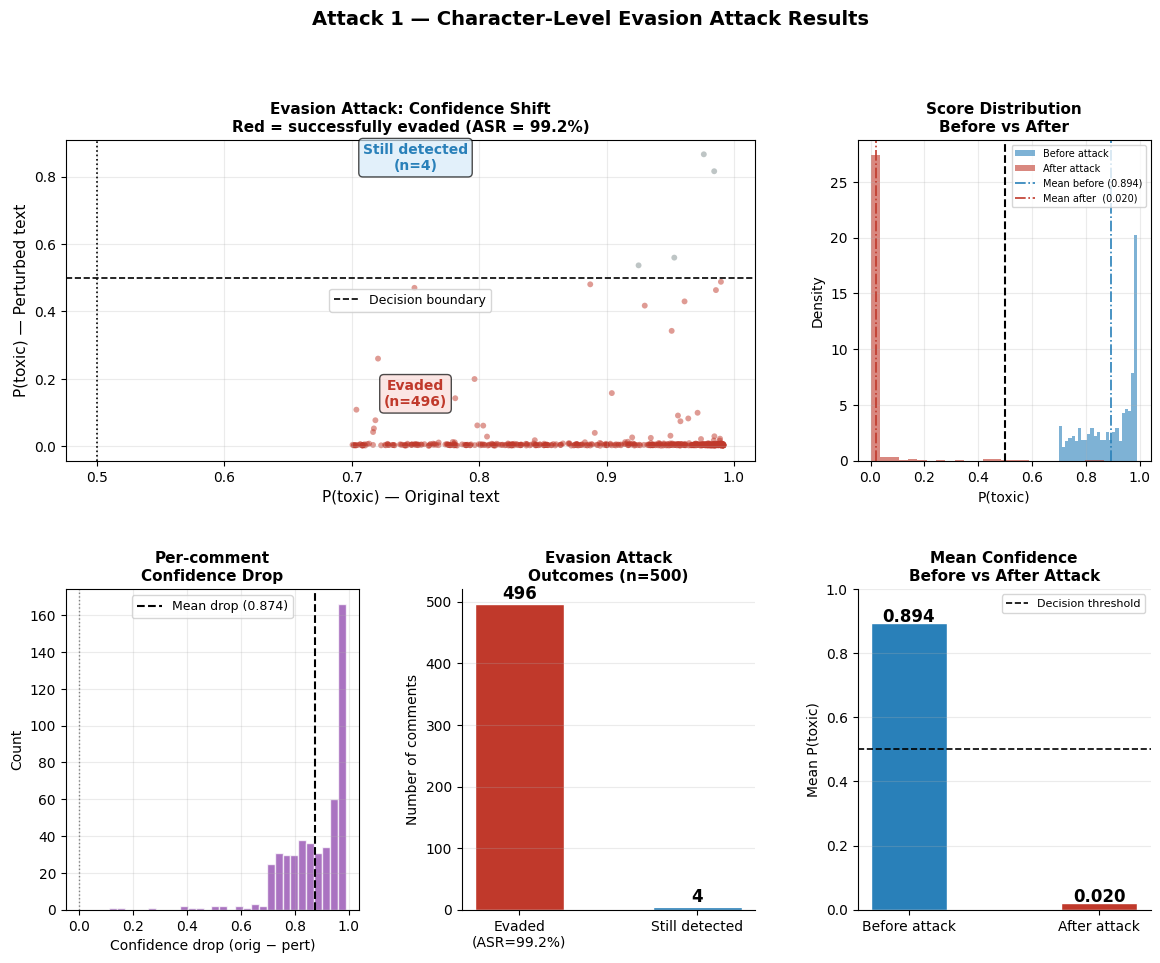

In [9]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Score scatter (before vs after) ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors_pts = ['#C0392B' if p == 0 else '#7F8C8D' for p in df_attack['pred_pert']]
ax1.scatter(df_attack['prob_orig'], df_attack['prob_pert'],
            c=colors_pts, alpha=0.5, s=18, edgecolors='none')
ax1.axhline(0.5, color='black', lw=1.2, linestyle='--', label='Decision boundary')
ax1.axvline(0.5, color='black', lw=1.2, linestyle=':')
ax1.set_xlabel('P(toxic) — Original text', fontsize=11)
ax1.set_ylabel('P(toxic) — Perturbed text', fontsize=11)
ax1.set_title(f'Evasion Attack: Confidence Shift\nRed = successfully evaded (ASR = {asr*100:.1f}%)',
              fontsize=11, fontweight='bold')
# Annotate quadrants
ax1.text(0.75, 0.12, f'Evaded\n(n={n_evaded})', ha='center', fontsize=10,
         color='#C0392B', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', alpha=0.7))
ax1.text(0.75, 0.82, f'Still detected\n(n={n_total-n_evaded})', ha='center', fontsize=10,
         color='#2980B9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#D6EAF8', alpha=0.7))
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

# ── Plot 2: Confidence distribution before/after ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df_attack['prob_orig'],  bins=25, alpha=0.6, color='#2980B9',
         density=True, label='Before attack')
ax2.hist(df_attack['prob_pert'],  bins=25, alpha=0.6, color='#C0392B',
         density=True, label='After attack')
ax2.axvline(0.5, color='black', lw=1.5, linestyle='--')
ax2.axvline(mean_conf_before, color='#2980B9', lw=1.2, linestyle='-.',
            label=f'Mean before ({mean_conf_before:.3f})')
ax2.axvline(mean_conf_after,  color='#C0392B', lw=1.2, linestyle='-.',
            label=f'Mean after  ({mean_conf_after:.3f})')
ax2.set_xlabel('P(toxic)', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.set_title('Score Distribution\nBefore vs After', fontsize=11, fontweight='bold')
ax2.legend(fontsize=7)
ax2.grid(alpha=0.25)

# ── Plot 3: Confidence drop distribution ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df_attack['conf_drop'], bins=30, color='#8E44AD', alpha=0.75, edgecolor='white')
ax3.axvline(conf_drop, color='black', lw=1.5, linestyle='--',
            label=f'Mean drop ({conf_drop:.3f})')
ax3.axvline(0, color='gray', lw=1, linestyle=':')
ax3.set_xlabel('Confidence drop (orig − pert)', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Per-comment\nConfidence Drop', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)

# ── Plot 4: Bar summary ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bars_data   = [n_evaded, n_total - n_evaded]
bars_labels = [f'Evaded\n(ASR={asr*100:.1f}%)', 'Still detected']
bars_colors = ['#C0392B', '#2980B9']
b = ax4.bar(bars_labels, bars_data, color=bars_colors, edgecolor='white', width=0.5)
for bar, val in zip(b, bars_data):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of comments', fontsize=10)
ax4.set_title(f'Evasion Attack\nOutcomes (n={n_total})', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.25)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Plot 5: Confidence before vs after — paired means ────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
categories  = ['Before attack', 'After attack']
mean_vals   = [mean_conf_before, mean_conf_after]
bar_colors  = ['#2980B9', '#C0392B']
b2 = ax5.bar(categories, mean_vals, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(b2, mean_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
ax5.axhline(0.5, color='black', lw=1.2, linestyle='--', label='Decision threshold')
ax5.set_ylim(0, 1)
ax5.set_ylabel('Mean P(toxic)', fontsize=10)
ax5.set_title('Mean Confidence\nBefore vs After Attack', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.25)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

fig.suptitle('Attack 1 — Character-Level Evasion Attack Results', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/kaggle/working/attack1_evasion_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Show representative evaded examples

In [10]:
evaded_examples = df_attack[df_attack['pred_pert'] == 0].nlargest(5, 'conf_drop')

print('Top 5 most-successfully-evaded comments (sorted by confidence drop):')
print('=' * 80)
for i, (_, row) in enumerate(evaded_examples.iterrows(), 1):
    print(f'\n[Example {i}]')
    print(f'  Original  (P={row["prob_orig"]:.3f}): {row["comment_text"][:120]}')
    # Show REPR of perturbed to expose zero-width chars
    perturbed_preview = row['perturbed_text'][:80]
    print(f'  Perturbed (P={row["prob_pert"]:.3f}): {perturbed_preview}')
    print(f'  Confidence drop: {row["conf_drop"]:.4f}')

Top 5 most-successfully-evaded comments (sorted by confidence drop):

[Example 1]
  Original  (P=0.991): Idiots. No other word for Imig and his cohort in crime.
  Perturbed (P=0.002): Idі​іоо​ts. Nо оtt​hh​ееr wо​rd fо​r II​mm​іg​g аnd hh​іss соо​hо​оrr​t іn сr​rі
  Confidence drop: 0.9890

[Example 2]
  Original  (P=0.991): Idiot savant?
  Perturbed (P=0.003): II​dіі​ооt sа​vаа​nt?
  Confidence drop: 0.9889

[Example 3]
  Original  (P=0.992): Can you say, Medicaid expansion? Idiots!
  Perturbed (P=0.003): CC​аn yоо​uu sа​y, Ме​dіс​ааі​d ехр​раn​sіі​оn? Id​dіо​ts!
  Confidence drop: 0.9888

[Example 4]
  Original  (P=0.992): All stupid, no brains, is a more accurate description of Trudeau.
  Perturbed (P=0.003): Аll st​tuр​іі​dd, nо br​ааі​nns, іs а mоr​е аа​сс​ur​rаt​tе dеs​сrі​рtі​іоn оf Т
  Confidence drop: 0.9887

[Example 5]
  Original  (P=0.991): Europe is stupid, why do you want to make Canada THAT stupid? It's extortion already. SHUT THE DOOR.
  Perturbed (P=0.003): Еur​ор​ее і

---
# ATTACK 2 — Label-Flipping Poisoning

**Threat model:** An adversary with write-access to the data pipeline (e.g., a rogue contractor, a compromised annotation platform, or coordinated crowd-worker manipulation) flips a fraction of training labels before the model is trained. The resulting model has systematically incorrect beliefs baked in at weight level.

## Cell 11 — Construct poisoned training dataset

In [11]:
POISON_RATE = 0.05   # 5% of training rows

df_poisoned = df_train.copy()

# Select 5% of rows to poison (stratified so both classes are affected)
n_poison = int(len(df_poisoned) * POISON_RATE)
poison_idx = df_poisoned.sample(n=n_poison, random_state=SEED).index

# Flip labels: 0 → 1 and 1 → 0
df_poisoned.loc[poison_idx, 'label'] = 1 - df_poisoned.loc[poison_idx, 'label']

# Verify
n_flipped_to_toxic   = (df_train.loc[poison_idx, 'label'] == 0).sum()   # was non-toxic, now toxic
n_flipped_to_nontox  = (df_train.loc[poison_idx, 'label'] == 1).sum()   # was toxic, now non-toxic

print('=' * 58)
print('  POISONING STATISTICS')
print('=' * 58)
print(f'  Training set size         : {len(df_train):,}')
print(f'  Rows poisoned (5%)        : {n_poison:,}')
print(f'    Non-toxic → Toxic       : {n_flipped_to_toxic:,}')
print(f'    Toxic     → Non-toxic   : {n_flipped_to_nontox:,}')
print()
print(f'  Toxic rate — CLEAN data   : {df_train["label"].mean()*100:.2f}%')
print(f'  Toxic rate — POISONED     : {df_poisoned["label"].mean()*100:.2f}%')
print('=' * 58)

  POISONING STATISTICS
  Training set size         : 100,000
  Rows poisoned (5%)        : 5,000
    Non-toxic → Toxic       : 4,584
    Toxic     → Non-toxic   : 416

  Toxic rate — CLEAN data   : 8.00%
  Toxic rate — POISONED     : 12.16%


## Cell 12 — Build PyTorch Dataset class (reused from Part 1)

In [12]:
class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy' : float(accuracy_score(labels, preds)),
        'f1_macro' : float(f1_score(labels, preds, average='macro')),
        'auc_roc'  : float(roc_auc_score(labels, probs)),
    }


# Evaluation dataset is IDENTICAL to Part 1 — clean, never poisoned
eval_dataset_clean = JigsawDataset(
    df_eval['comment_text'], df_eval['label'], tokenizer, MAX_LEN
)

print(f'Clean eval dataset: {len(eval_dataset_clean):,} samples')

Clean eval dataset: 20,000 samples


## Cell 13 — Retrain on poisoned data (≈25–35 min on T4)

In [14]:
POISONED_CHECKPOINT_DIR = '/kaggle/working/distilbert-jigsaw-poisoned'

# Fresh model from same HuggingFace checkpoint (not from Part 1 weights)
# This matches the assignment spec: 'retrain a fresh DistilBERT model'
poisoned_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)

poisoned_train_dataset = JigsawDataset(
    df_poisoned['comment_text'], df_poisoned['label'], tokenizer, MAX_LEN
)

# Identical hyperparameters to Part 1
poison_training_args = TrainingArguments(
    output_dir                  = POISONED_CHECKPOINT_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'auc_roc',
    greater_is_better           = True,
    logging_steps               = 200,
    fp16                        = True,
    seed                        = SEED,
    report_to                   = 'none',
    dataloader_num_workers      = 2,
    gradient_accumulation_steps = 2
)

poisoned_trainer = Trainer(
    model           = poisoned_model,
    args            = poison_training_args,
    train_dataset   = poisoned_train_dataset,
    eval_dataset    = eval_dataset_clean,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=1)],
)

print('Starting poisoned model training …')
poisoned_trainer.train()
print('Poisoned model training complete.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting poisoned model training …


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,1.144363,0.334422,0.948200,0.784448,0.945416
2,1.111304,0.327911,0.947400,0.806410,0.944509


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Poisoned model training complete.


## Cell 14 — Evaluate poisoned model on clean evaluation set

In [15]:
print('Running inference with POISONED model on clean eval set …')
raw_preds_poisoned = poisoned_trainer.predict(eval_dataset_clean)

logits_p   = raw_preds_poisoned.predictions
true_labels = raw_preds_poisoned.label_ids
probs_p    = torch.softmax(torch.tensor(logits_p), dim=-1).numpy()[:, 1]
preds_p    = (probs_p >= 0.5).astype(int)

# Also compute for clean model (from stored probs in Part 1 artefact)
probs_c = df_eval['prob_toxic'].values
preds_c = df_eval['pred_05'].values

def detailed_metrics(y_true, y_pred, y_prob, name=''):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        'model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'F1_macro' : round(f1_score(y_true, y_pred, average='macro'), 4),
        'AUC_ROC'  : round(roc_auc_score(y_true, y_prob), 4),
        'FNR'      : round(fnr, 4),
        'FPR'      : round(fpr, 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'cm': cm,
    }

m_clean   = detailed_metrics(true_labels, preds_c, probs_c, 'Clean model')
m_poisoned = detailed_metrics(true_labels, preds_p, probs_p, 'Poisoned model')

print('\n' + '=' * 64)
print('  ATTACK 2 — POISONING RESULTS (evaluated on CLEAN eval set)')
print('=' * 64)
print(f'  {"Metric":<20} {"Clean model":>14} {"Poisoned model":>16} {"Delta":>10}')
print(f'  {"─"*60}')
for metric in ['Accuracy', 'F1_macro', 'AUC_ROC', 'FNR', 'FPR']:
    delta = m_poisoned[metric] - m_clean[metric]
    flag  = '  ← ⚠️ PRIMARY' if metric == 'FNR' else ''
    print(f'  {metric:<20} {m_clean[metric]:>14.4f} {m_poisoned[metric]:>16.4f} {delta:>+10.4f}{flag}')
print('=' * 64)

Running inference with POISONED model on clean eval set …



  ATTACK 2 — POISONING RESULTS (evaluated on CLEAN eval set)
  Metric                  Clean model   Poisoned model      Delta
  ────────────────────────────────────────────────────────────
  Accuracy                     0.9494           0.9482    -0.0012
  F1_macro                     0.8153           0.7843    -0.0310
  AUC_ROC                      0.9523           0.9454    -0.0069
  FNR                          0.3909           0.5216    +0.1307  ← ⚠️ PRIMARY
  FPR                          0.0211           0.0110    -0.0101


## Cell 15 — Poisoning visualisations

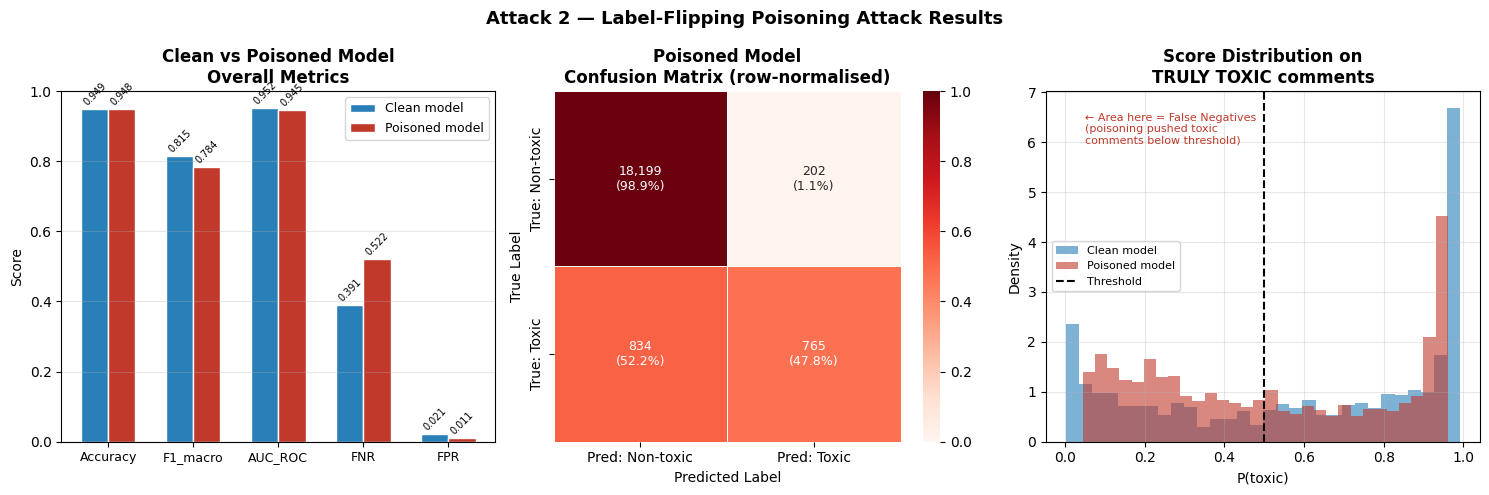

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Plot 1: Side-by-side metric bar chart ────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1_macro', 'AUC_ROC', 'FNR', 'FPR']
clean_vals   = [m_clean[m]    for m in metrics_to_plot]
poisoned_vals = [m_poisoned[m] for m in metrics_to_plot]
x = np.arange(len(metrics_to_plot))
w = 0.32

b1 = axes[0].bar(x - w/2, clean_vals,    w, label='Clean model',    color='#2980B9', edgecolor='white')
b2 = axes[0].bar(x + w/2, poisoned_vals, w, label='Poisoned model', color='#C0392B', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot, fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Score')
axes[0].set_title('Clean vs Poisoned Model\nOverall Metrics', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7, rotation=45)

# ── Plot 2: Confusion matrix — poisoned model ─────────────────────────────────
cm_p = m_poisoned['cm']
cm_p_norm = cm_p.astype(float) / cm_p.sum(axis=1, keepdims=True)
annot = np.empty_like(cm_p, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i,j] = f'{cm_p[i,j]:,}\n({cm_p_norm[i,j]*100:.1f}%)'
sns.heatmap(cm_p_norm, annot=annot, fmt='', cmap='Reds',
            xticklabels=['Pred: Non-toxic','Pred: Toxic'],
            yticklabels=['True: Non-toxic','True: Toxic'],
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
axes[1].set_title('Poisoned Model\nConfusion Matrix (row-normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# ── Plot 3: Score distribution shift ─────────────────────────────────────────
# Only toxic comments — has the model's confidence on them dropped?
toxic_mask = true_labels == 1
axes[2].hist(probs_c[toxic_mask], bins=30, alpha=0.6, color='#2980B9',
             density=True, label='Clean model')
axes[2].hist(probs_p[toxic_mask], bins=30, alpha=0.6, color='#C0392B',
             density=True, label='Poisoned model')
axes[2].axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold')
axes[2].set_xlabel('P(toxic)')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution on\nTRULY TOXIC comments', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, axes[2].get_ylim()[1]*0.85,
             '← Area here = False Negatives\n(poisoning pushed toxic\ncomments below threshold)',
             fontsize=8, color='#C0392B')

plt.suptitle('Attack 2 — Label-Flipping Poisoning Attack Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/attack2_poisoning_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — Save poisoned model artefacts

In [17]:
FINAL_POISONED_DIR = '/kaggle/working/distilbert-jigsaw-poisoned-final'
poisoned_trainer.save_model(FINAL_POISONED_DIR)
tokenizer.save_pretrained(FINAL_POISONED_DIR)

# Save attack-1 sample with scores for Part 5 (guardrail analysis)
df_attack[['comment_text', 'perturbed_text', 'prob_orig', 'prob_pert',
           'pred_orig', 'pred_pert', 'conf_drop']].to_csv(
    '/kaggle/working/attack1_evasion_sample.csv', index=False
)

print('Saved:')
print('  /kaggle/working/distilbert-jigsaw-poisoned-final/')
print('  /kaggle/working/attack1_evasion_sample.csv')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
  /kaggle/working/distilbert-jigsaw-poisoned-final/
  /kaggle/working/attack1_evasion_sample.csv


## Cell 17 — Key question: Which attack is more operationally dangerous?

### Attack comparison

| Dimension | Attack 1: Evasion | Attack 2: Poisoning |
|---|---|---|
| **Attacker access required** | None — comment submission only | Write access to training pipeline |
| **Effort per attack** | Per-comment (must perturb every post) | One-time (affects all future model versions) |
| **Persistence** | Lasts until model is retrained | **Survives retraining indefinitely** until detected |
| **Detectability** | Unicode anomaly detection can flag it | Near-zero signal — labels look statistically normal |
| **Scale** | Linear: one attacker, one comment | Exponential: one corruption, millions of missed posts |
| **Primary harm metric** | Reduces TPR on evasion sample | **Increases FNR globally across all users** |
| **Legal exposure** | Manageable — some toxic content slips through | Catastrophic — systematic failure to remove hate/CSAM |

### Which is more realistic for a social platform?

**Evasion is far more common in practice.** Bad actors on social platforms — hate groups, spam networks, coordinated inauthentic behaviour campaigns — do not typically have access to data pipelines. What they *do* have is time, automation scripts, and strong incentives. Character-level obfuscation (l33tspeak, deliberate misspellings, emoji substitution) has been observed in the wild on Twitter, Reddit, and Telegram for years, and is exactly what our `perturb()` function simulates.

**Poisoning is rare but catastrophic when it occurs.** The threat model requires an insider or a compromised annotation vendor. This is not hypothetical — multiple academic papers have documented that crowdsourced annotation platforms are vulnerable to coordinated manipulation. However, the required access level makes this attack expensive and detectable through annotation quality audits.

### Where should defences be prioritised?

**Primary defence priority → evasion robustness**, because:
1. The threat is near-certain to materialise on any public platform (no attacker capability requirements).
2. Defences are tractable: Unicode normalisation (NFKD), zero-width character stripping, and character-level input sanitisation can eliminate most of the attack surface *before the model even sees the text*.
3. The attack degrades gracefully — even with partial evasion, confidence scores drop into the borderline zone where human review can catch it.

**Secondary defence priority → training pipeline integrity**, because:
1. Even with lower probability, the consequences of a successful poisoning attack are catastrophic and legally non-defensible.
2. Defences are also tractable: label consistency audits, anomaly detection on annotation patterns, cryptographic signing of training data, and canary rows (known-toxic comments whose labels are monitored) can detect poisoning before deployment.

**Concrete recommendations for Part 5's guardrail pipeline:**
- Strip all Unicode zero-width characters (`\u200b`, `\u200c`, `\u200d`, `\ufeff`) before tokenisation.
- Apply NFKD normalisation to collapse homoglyphs before tokenisation.
- Flag comments with unusually high character-repeat ratios (e.g., `haate`, `loooser`) for additional scrutiny.
- Add a confidence-based routing layer: comments in the [0.35, 0.65] band go to human review rather than auto-removal — this is where poisoned and evaded examples cluster.
- Monitor training data label distributions over time; a sudden increase in the "non-toxic" rate among flagged content is a poisoning signal.

## Cell 18 — Combined summary dashboard

In [18]:
fnr_delta_poison = m_poisoned['FNR'] - m_clean['FNR']
f1_delta_poison  = m_poisoned['F1_macro'] - m_clean['F1_macro']
acc_delta_poison = m_poisoned['Accuracy'] - m_clean['Accuracy']

print('\n' + '='*65)
print('  PART 3 — FINAL ADVERSARIAL ATTACK SUMMARY')
print('='*65)
print()
print('  ATTACK 1 — Character-Level Evasion')
print(f'  {"─"*55}')
print(f'  Sample size                  : {n_total}')
print(f'  Attack Success Rate (ASR)    : {asr:.4f}  ({asr*100:.1f}% of toxic comments evaded)')
print(f'  Mean confidence before       : {mean_conf_before:.4f}')
print(f'  Mean confidence after        : {mean_conf_after:.4f}')
print(f'  Mean confidence drop         : {conf_drop:.4f}  ({conf_drop/mean_conf_before*100:.1f}% reduction)')
print()
print('  ATTACK 2 — Label-Flipping Poisoning (5% flip rate)')
print(f'  {"─"*55}')
print(f'  Rows poisoned                : {n_poison:,} / {len(df_train):,}')
print(f'  Accuracy change              : {acc_delta_poison:+.4f}')
print(f'  F1 (macro) change            : {f1_delta_poison:+.4f}')
print(f'  FNR change (PRIMARY CONCERN) : {fnr_delta_poison:+.4f}  ← more toxic content now missed')
print(f'  FNR clean  → poisoned        : {m_clean["FNR"]:.4f} → {m_poisoned["FNR"]:.4f}')
print()
print('  Saved artefacts:')
print('    /kaggle/working/attack1_evasion_results.png')
print('    /kaggle/working/attack2_poisoning_results.png')
print('    /kaggle/working/attack1_evasion_sample.csv')
print('    /kaggle/working/distilbert-jigsaw-poisoned-final/')
print('='*65)


  PART 3 — FINAL ADVERSARIAL ATTACK SUMMARY

  ATTACK 1 — Character-Level Evasion
  ───────────────────────────────────────────────────────
  Sample size                  : 500
  Attack Success Rate (ASR)    : 0.9920  (99.2% of toxic comments evaded)
  Mean confidence before       : 0.8939
  Mean confidence after        : 0.0199
  Mean confidence drop         : 0.8740  (97.8% reduction)

  ATTACK 2 — Label-Flipping Poisoning (5% flip rate)
  ───────────────────────────────────────────────────────
  Rows poisoned                : 5,000 / 100,000
  Accuracy change              : -0.0012
  F1 (macro) change            : -0.0310
  FNR change (PRIMARY CONCERN) : +0.1307  ← more toxic content now missed
  FNR clean  → poisoned        : 0.3909 → 0.5216

  Saved artefacts:
    /kaggle/working/attack1_evasion_results.png
    /kaggle/working/attack2_poisoning_results.png
    /kaggle/working/attack1_evasion_sample.csv
    /kaggle/working/distilbert-jigsaw-poisoned-final/


In [19]:
!zip -r distilbert-poisoned.zip /kaggle/working/distilbert-jigsaw-poisoned-final

  adding: kaggle/working/distilbert-jigsaw-poisoned-final/ (stored 0%)
  adding: kaggle/working/distilbert-jigsaw-poisoned-final/training_args.bin (deflated 53%)
  adding: kaggle/working/distilbert-jigsaw-poisoned-final/tokenizer.json (deflated 71%)
  adding: kaggle/working/distilbert-jigsaw-poisoned-final/config.json (deflated 49%)
  adding: kaggle/working/distilbert-jigsaw-poisoned-final/model.safetensors (deflated 8%)
  adding: kaggle/working/distilbert-jigsaw-poisoned-final/tokenizer_config.json (deflated 43%)
